# 05 — Traditional Image Augmentation

## Project
**Identity-Preserving Synthetic Ocular Image Generation Using Conditional Diffusion Models**

## Dataset
**CASIA-Iris-Thousand**

## Objective

This notebook performs traditional image augmentation on the CASIA-Iris-Thousand
training dataset.

Traditional augmentation is used as the first augmentation-based experiment
before implementing GAN-based and diffusion-based image generation.

The purpose is to increase the variability of the training images while
preserving the underlying ocular identity.

## Augmentation Techniques

The following transformations will be investigated:

1. Small random rotation
2. Small translation
3. Small scaling
4. Brightness variation
5. Contrast variation
6. Slight image blur

Aggressive transformations such as horizontal flipping are avoided because
left-eye and right-eye information is meaningful in ocular recognition.

## Experimental Rule

Only the training images will be augmented.

- Training set: Augmented
- Validation set: Unchanged
- Test set: Unchanged

The same validation and test sets used in the baseline experiment will be
maintained so that the traditional augmentation experiment can be compared
fairly with the baseline recognition experiment.

## Dataset Split

- Training images: 12,000
- Validation images: 4,000
- Test images: 4,000
- Total images: 20,000
- Eye identities: 2,000

## Experiment Flow

Original Training Images
        ↓
Traditional Augmentation
        ↓
Augmented Training Data
        ↓
Recognition Model
        ↓
Validation / Test Evaluation
        ↓
Comparison with Baseline

In [1]:
# Cell 2 — Import Required Libraries

import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

print("Libraries imported successfully.")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Libraries imported successfully.
PyTorch version: 2.11.0+cu128
CUDA available: True


In [2]:
# Cell 3 — Mount Google Drive and Set Project Paths

from google.colab import drive

drive.mount("/content/drive")

project_path = Path("/content/drive/MyDrive/Ocular_Project")

dataset_path = (
    project_path
    / "datasets"
    / "CASIA-Iris-Thousand"
    / "CASIA-Iris-Thousand"
    / "CASIA-Iris-Thousand"
)

split_csv_path = (
    project_path
    / "results"
    / "CASIA_Thousand_data_split.csv"
)

print("Project path:", project_path)
print("Dataset path:", dataset_path)
print("Split CSV:", split_csv_path)

Mounted at /content/drive
Project path: /content/drive/MyDrive/Ocular_Project
Dataset path: /content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand
Split CSV: /content/drive/MyDrive/Ocular_Project/results/CASIA_Thousand_data_split.csv


In [4]:
# Cell 4 — Load and Verify Dataset Split

split_df = pd.read_csv(split_csv_path)

print("Dataset split loaded successfully.")
print()

print("Total images:", len(split_df))
print("Training images:", (split_df["split"] == "train").sum())
print("Validation images:", (split_df["split"] == "validation").sum())
print("Test images:", (split_df["split"] == "test").sum())

print()
print("Number of eye identities:", split_df["identity"].nunique())

print()
print("Split distribution:")
print(split_df["split"].value_counts())

Dataset split loaded successfully.

Total images: 20000
Training images: 12000
Validation images: 4000
Test images: 4000

Number of eye identities: 2000

Split distribution:
split
train         12000
validation     4000
test           4000
Name: count, dtype: int64


In [5]:
# Cell 5 — Create Train, Validation and Test DataFrames

train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df = split_df[split_df["split"] == "validation"].reset_index(drop=True)
test_df = split_df[split_df["split"] == "test"].reset_index(drop=True)

print("Training set:", len(train_df))
print("Validation set:", len(val_df))
print("Test set:", len(test_df))

print()
print("Training identities:", train_df["identity"].nunique())
print("Validation identities:", val_df["identity"].nunique())
print("Test identities:", test_df["identity"].nunique())

Training set: 12000
Validation set: 4000
Test set: 4000

Training identities: 2000
Validation identities: 2000
Test identities: 2000


In [6]:
# Cell 6 — Define Traditional Augmentation Pipeline

traditional_augmentation = transforms.Compose([
    transforms.RandomRotation(
        degrees=8
    ),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 1.0)
        )
    ], p=0.10)
])

print("Traditional augmentation pipeline created successfully.")

Traditional augmentation pipeline created successfully.


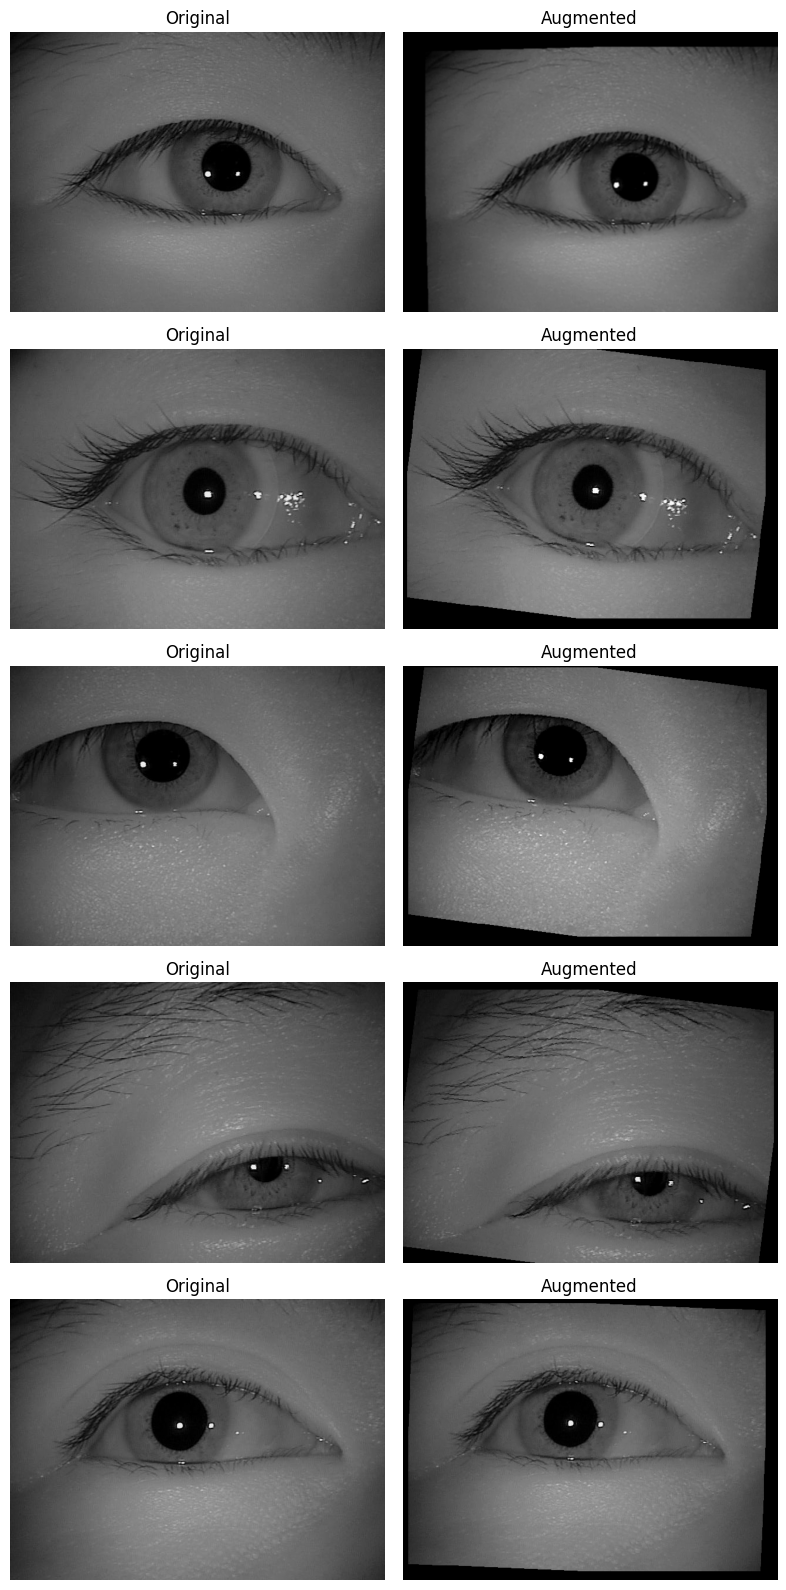

In [7]:
# Cell 7 — Visualize Traditional Augmentation

# Select a few training images
sample_df = train_df.sample(5, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(5, 2, figsize=(8, 16))

for i in range(5):
    image_path = sample_df.loc[i, "image_path"]

    # Load original image
    original_image = Image.open(image_path).convert("L")

    # Apply our traditional augmentation
    augmented_image = traditional_augmentation(original_image)

    # Display original
    axes[i, 0].imshow(original_image, cmap="gray")
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    # Display augmented
    axes[i, 1].imshow(augmented_image, cmap="gray")
    axes[i, 1].set_title("Augmented")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [17]:
# Cell 8 — Final Traditional Augmentation Pipeline

traditional_augmentation = transforms.Compose([
    # Convert original 640x480 image to square
    transforms.CenterCrop(480),

    # Mild random crop and resize
    transforms.RandomResizedCrop(
        size=(256, 256),
        scale=(0.95, 1.0),
        ratio=(0.98, 1.02)
    ),

    # Small appearance variations
    transforms.ColorJitter(
        brightness=0.12,
        contrast=0.12
    ),

    # Occasional slight blur
    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 0.8)
        )
    ], p=0.10),

    # Convert PIL image to PyTorch tensor
    transforms.ToTensor()
])

print("Final traditional augmentation pipeline created.")

Final traditional augmentation pipeline created.


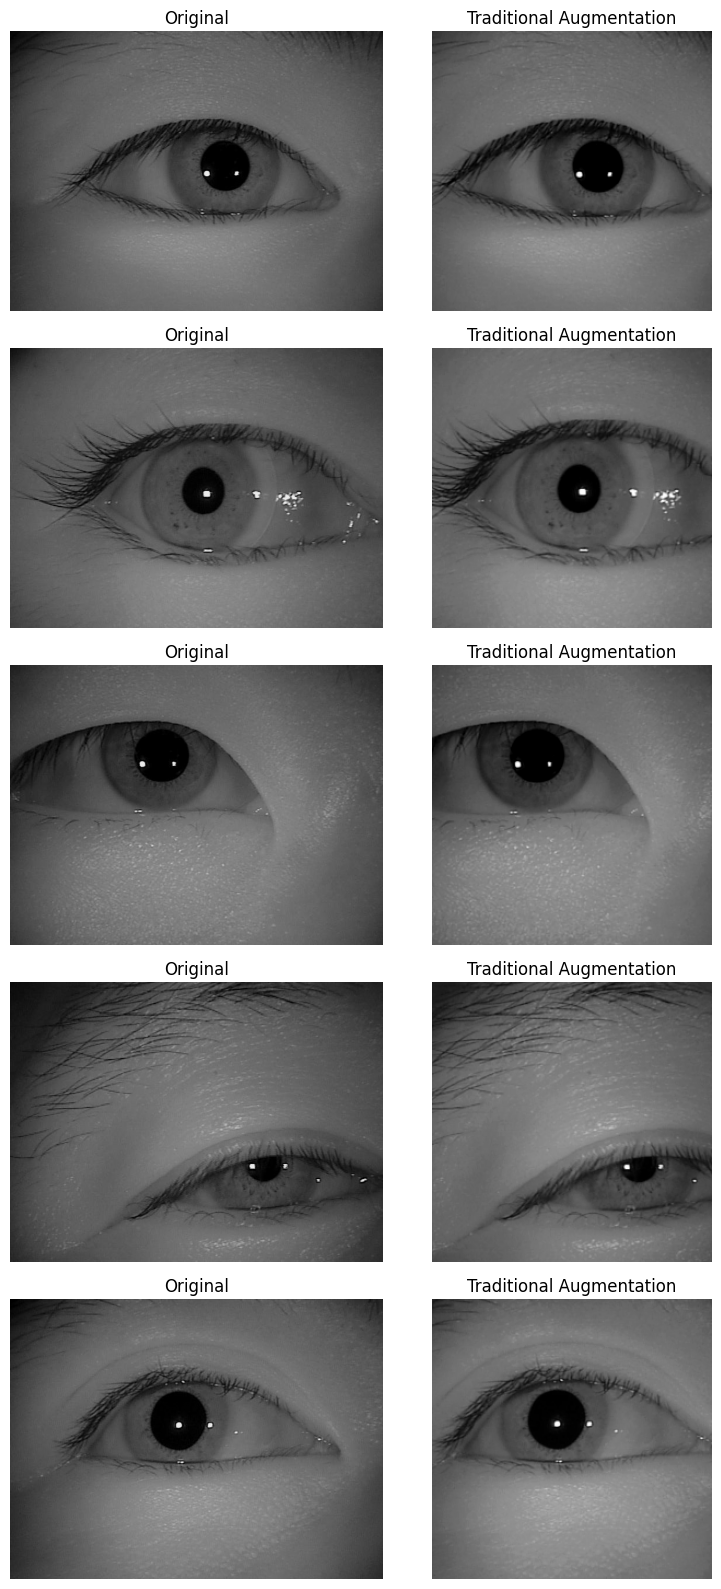

In [20]:
# Cell 9 — Verify Final Traditional Augmentation

sample_df = train_df.sample(5, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(5, 2, figsize=(8, 16))

for i in range(5):
    image_path = sample_df.loc[i, "image_path"]

    # Load original image
    original_image = Image.open(image_path).convert("L")

    # Apply final augmentation
    augmented_image = traditional_augmentation(original_image)

    # Original
    axes[i, 0].imshow(original_image, cmap="gray")
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    # Augmented tensor -> remove channel dimension for visualization
    axes[i, 1].imshow(
        augmented_image.squeeze(0),
        cmap="gray"
    )
    axes[i, 1].set_title("Traditional Augmentation")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [21]:
# Cell 10 — Create Dataset Class for Traditional Augmentation

class TraditionalAugmentedDataset(Dataset):
    def __init__(self, dataframe, transform=None, identity_to_label=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.identity_to_label = identity_to_label

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = row["image_path"]
        identity = row["identity"]

        # Load grayscale ocular image
        image = Image.open(image_path).convert("L")

        # Apply augmentation
        if self.transform:
            image = self.transform(image)

        # Convert identity to numerical label
        label = self.identity_to_label[identity]

        return image, label


print("Traditional augmented dataset class created successfully.")

Traditional augmented dataset class created successfully.


In [22]:
# Cell 11 — Create Identity-to-Label Mapping

identities = sorted(split_df["identity"].unique())

identity_to_label = {
    identity: label
    for label, identity in enumerate(identities)
}

num_identities = len(identity_to_label)

print("Number of identities:", num_identities)
print()
print("First 10 identity labels:")

for identity in identities[:10]:
    print(identity, "->", identity_to_label[identity])

print()
print("Last 5 identity labels:")

for identity in identities[-5:]:
    print(identity, "->", identity_to_label[identity])

Number of identities: 2000

First 10 identity labels:
000_L -> 0
000_R -> 1
001_L -> 2
001_R -> 3
002_L -> 4
002_R -> 5
003_L -> 6
003_R -> 7
004_L -> 8
004_R -> 9

Last 5 identity labels:
997_R -> 1995
998_L -> 1996
998_R -> 1997
999_L -> 1998
999_R -> 1999


In [23]:
# Cell 12 — Create Training, Validation and Test Datasets

# Normal preprocessing for validation and test
base_transform = transforms.Compose([
    transforms.CenterCrop(480),
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# Training dataset with traditional augmentation
train_dataset = TraditionalAugmentedDataset(
    dataframe=train_df,
    transform=traditional_augmentation,
    identity_to_label=identity_to_label
)

# Validation dataset — NO augmentation
val_dataset = TraditionalAugmentedDataset(
    dataframe=val_df,
    transform=base_transform,
    identity_to_label=identity_to_label
)

# Test dataset — NO augmentation
test_dataset = TraditionalAugmentedDataset(
    dataframe=test_df,
    transform=base_transform,
    identity_to_label=identity_to_label
)

print("Datasets created successfully.")
print()
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Datasets created successfully.

Training samples: 12000
Validation samples: 4000
Test samples: 4000


In [24]:
# Cell 13 — Create DataLoaders

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created successfully.")
print()
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

DataLoaders created successfully.

Training batches: 375
Validation batches: 125
Test batches: 125


In [25]:
# Cell 14 — Verify Training Batch

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print()
print("Image data type:", images.dtype)
print("Label data type:", labels.dtype)

print()
print("Pixel value range:")
print("Minimum:", images.min().item())
print("Maximum:", images.max().item())

print()
print("First 10 labels:", labels[:10].tolist())

Image batch shape: torch.Size([32, 1, 256, 256])
Label batch shape: torch.Size([32])

Image data type: torch.float32
Label data type: torch.int64

Pixel value range:
Minimum: 0.0
Maximum: 1.0

First 10 labels: [366, 1564, 1323, 1669, 1009, 1296, 329, 1336, 1371, 1225]


In [26]:
# Cell 15 — Training DataLoader Speed Test

import time

start_time = time.time()

for batch_idx, (images, labels) in enumerate(train_loader):
    if batch_idx == 9:
        break

elapsed_time = time.time() - start_time

print("10 training batches loaded successfully.")
print(f"Time taken: {elapsed_time:.2f} seconds")
print(f"Average time per batch: {elapsed_time / 10:.2f} seconds")

# Estimate full epoch time
estimated_epoch_time = (elapsed_time / 10) * len(train_loader)

print(f"Estimated time per epoch: {estimated_epoch_time / 60:.2f} minutes")

10 training batches loaded successfully.
Time taken: 116.09 seconds
Average time per batch: 11.61 seconds
Estimated time per epoch: 72.56 minutes


In [27]:
# Cell 16 — Update Image Paths to Local Colab Storage

# Local dataset extracted in Notebook 04
local_image_root = Path(
    "/content/CASIA-Iris-Thousand/"
    "CASIA-Iris-Thousand/"
    "CASIA-Iris-Thousand"
)

def get_local_path(identity, image_path):
    original_path = Path(image_path)

    filename = original_path.name
    subject = identity.split("_")[0]
    eye = identity.split("_")[1]

    return str(
        local_image_root
        / subject
        / eye
        / filename
    )

# Convert Drive paths to local paths
for df in [train_df, val_df, test_df]:
    df["image_path"] = df.apply(
        lambda row: get_local_path(
            row["identity"],
            row["image_path"]
        ),
        axis=1
    )

print("Image paths updated to local Colab storage.")
print()
print("Example local path:")
print(train_df.iloc[0]["image_path"])

print()
print("File exists:", Path(train_df.iloc[0]["image_path"]).exists())

Image paths updated to local Colab storage.

Example local path:
/content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000/L/S5000L00.jpg

File exists: False


In [28]:
# Cell 17 — Check Local Dataset

local_dataset_root = Path("/content/CASIA-Iris-Thousand")

print("Local dataset folder exists:",
      local_dataset_root.exists())

if local_dataset_root.exists():
    print("Contents of /content/CASIA-Iris-Thousand:")
    for item in local_dataset_root.iterdir():
        print(" -", item.name)
else:
    print("Local dataset is not currently available.")

Local dataset folder exists: False
Local dataset is not currently available.


In [29]:
# Cell 18 — Copy Dataset ZIP to Local Colab Storage

import shutil

zip_path = project_path / "datasets" / "archive.zip"
local_zip_path = Path("/content/CASIA-Iris-Thousand.zip")

print("Copying dataset ZIP to local Colab storage...")

shutil.copy2(zip_path, local_zip_path)

print("Dataset ZIP copied successfully.")
print(f"Local ZIP size: {local_zip_path.stat().st_size / (1024**2):.2f} MB")

Copying dataset ZIP to local Colab storage...
Dataset ZIP copied successfully.
Local ZIP size: 490.79 MB


In [30]:
# Cell 19 — Extract Dataset to Local Storage

import zipfile

local_extract_path = Path("/content/CASIA-Iris-Thousand")

print("Extracting dataset...")

with zipfile.ZipFile(local_zip_path, "r") as zip_ref:
    zip_ref.extractall(local_extract_path.parent)

print("Dataset extracted successfully.")

Extracting dataset...
Dataset extracted successfully.


In [31]:
# Cell 20 — Verify Local Dataset Structure

local_image_root = (
    Path("/content/CASIA-Iris-Thousand")
    / "CASIA-Iris-Thousand"
    / "CASIA-Iris-Thousand"
)

print("Local image root:")
print(local_image_root)

print()
print("Root exists:", local_image_root.exists())

# Check a subject folder
subject_000 = local_image_root / "000"

print("Subject 000 exists:", subject_000.exists())

if subject_000.exists():
    print()
    print("Contents of subject 000:")
    for item in subject_000.iterdir():
        print(" -", item.name)

# Check one actual image
sample_image = local_image_root / "000" / "L" / "S5000L00.jpg"

print()
print("Sample image exists:", sample_image.exists())

if sample_image.exists():
    image = Image.open(sample_image)
    print("Sample image size:", image.size)
    print("Sample image mode:", image.mode)

Local image root:
/content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand

Root exists: False
Subject 000 exists: False

Sample image exists: False


In [32]:
# Cell 21 — Inspect Extracted Dataset Structure

extract_base = Path("/content")

print("Folders/files directly inside /content:")
for item in extract_base.iterdir():
    print(" -", item.name)

print("\nSearching for subject folder '000'...")

subject_matches = list(extract_base.rglob("000"))

print("Number of matches:", len(subject_matches))

for match in subject_matches[:10]:
    print(" -", match)

Folders/files directly inside /content:
 - .config
 - iris_thousands.csv
 - CASIA-Iris-Thousand.zip
 - CASIA-Iris-Thousand
 - drive
 - sample_data

Searching for subject folder '000'...
Number of matches: 3
 - /content/drive/.Encrypted/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000
 - /content/drive/MyDrive/Ocular_Project/datasets/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000
 - /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000


In [33]:
# Cell 22 — Set Correct Local Dataset Path

local_image_root = (
    Path("/content/CASIA-Iris-Thousand")
    / "CASIA-Iris-Thousand"
)

print("Correct local image root:")
print(local_image_root)

print()
print("Root exists:", local_image_root.exists())

# Check sample image
sample_image = (
    local_image_root
    / "000"
    / "L"
    / "S5000L00.jpg"
)

print("Sample image exists:", sample_image.exists())

if sample_image.exists():
    image = Image.open(sample_image)
    print("Sample image size:", image.size)
    print("Sample image mode:", image.mode)

Correct local image root:
/content/CASIA-Iris-Thousand/CASIA-Iris-Thousand

Root exists: True
Sample image exists: True
Sample image size: (640, 480)
Sample image mode: L


In [34]:
# Cell 23 — Rebuild Image Paths Using Local Dataset

# Reload the original split CSV so we start with the original Drive paths
split_df = pd.read_csv(split_csv_path)

# Recreate the three DataFrames
train_df = split_df[split_df["split"] == "train"].reset_index(drop=True)
val_df = split_df[split_df["split"] == "validation"].reset_index(drop=True)
test_df = split_df[split_df["split"] == "test"].reset_index(drop=True)


def get_local_path(identity, image_path):
    filename = Path(image_path).name

    subject = identity.split("_")[0]
    eye = identity.split("_")[1]

    return str(
        local_image_root
        / subject
        / eye
        / filename
    )


# Convert all paths to local Colab paths
for df in [train_df, val_df, test_df]:
    df["image_path"] = df.apply(
        lambda row: get_local_path(
            row["identity"],
            row["image_path"]
        ),
        axis=1
    )


# Verify paths
print("Local paths rebuilt successfully.")
print()

print("Example training path:")
print(train_df.iloc[0]["image_path"])

print()
print("Training file exists:",
      Path(train_df.iloc[0]["image_path"]).exists())

print("Validation file exists:",
      Path(val_df.iloc[0]["image_path"]).exists())

print("Test file exists:",
      Path(test_df.iloc[0]["image_path"]).exists())

Local paths rebuilt successfully.

Example training path:
/content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000/L/S5000L00.jpg

Training file exists: True
Validation file exists: True
Test file exists: True


In [35]:
# Cell 24 — Recreate Datasets and DataLoaders

# Create datasets using the corrected local paths

train_dataset = TraditionalAugmentedDataset(
    dataframe=train_df,
    transform=traditional_augmentation,
    identity_to_label=identity_to_label
)

val_dataset = TraditionalAugmentedDataset(
    dataframe=val_df,
    transform=base_transform,
    identity_to_label=identity_to_label
)

test_dataset = TraditionalAugmentedDataset(
    dataframe=test_df,
    transform=base_transform,
    identity_to_label=identity_to_label
)


# DataLoader settings
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print("Datasets and DataLoaders recreated successfully.")
print()
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

print()
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Datasets and DataLoaders recreated successfully.

Training samples: 12000
Validation samples: 4000
Test samples: 4000

Training batches: 375
Validation batches: 125
Test batches: 125


In [36]:
# Cell 25 — Training DataLoader Speed Test

import time

start_time = time.time()

for batch_idx, (images, labels) in enumerate(train_loader):
    if batch_idx == 9:
        break

elapsed_time = time.time() - start_time

print("10 training batches loaded successfully.")
print(f"Time taken: {elapsed_time:.2f} seconds")
print(f"Average time per batch: {elapsed_time / 10:.2f} seconds")

estimated_epoch_time = (elapsed_time / 10) * len(train_loader)

print(f"Estimated time per epoch: {estimated_epoch_time / 60:.2f} minutes")

10 training batches loaded successfully.
Time taken: 1.59 seconds
Average time per batch: 0.16 seconds
Estimated time per epoch: 1.00 minutes


In [38]:
# Cell 26 — Set Computing Device

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [39]:
# Cell 26 — Create ResNet18 for Traditional Augmentation Experiment

import torch.nn as nn
from torchvision import models

# Number of classes
num_identities = len(identity_to_label)

# Create ResNet18 from scratch
traditional_model = models.resnet18(weights=None)

# Change first convolution for grayscale images
traditional_model.conv1 = nn.Conv2d(
    1,
    64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

# Change final layer for 2,000 eye identities
traditional_model.fc = nn.Linear(
    traditional_model.fc.in_features,
    num_identities
)

# Move model to GPU
traditional_model = traditional_model.to(device)

print("Traditional augmentation ResNet18 created successfully.")
print("Number of output classes:", num_identities)
print("Device:", device)

Traditional augmentation ResNet18 created successfully.
Number of output classes: 2000
Device: cuda


In [40]:
# Cell 27 — Define Loss Function and Optimizer

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    traditional_model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", 0.001)

Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.001


In [41]:
# Cell 28 — Define Training Function

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = 100.0 * correct / total

    return epoch_loss, epoch_accuracy


print("Training function created successfully.")

Training function created successfully.


In [42]:
# Cell 29 — Define Validation Function

def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    # Disable gradient calculation during validation
    with torch.no_grad():

        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = 100.0 * correct / total

    return epoch_loss, epoch_accuracy


print("Validation function created successfully.")

Validation function created successfully.


In [43]:
# Cell 30 — Initialize Training History

num_epochs = 10

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

print("Training configuration:")
print("Number of epochs:", num_epochs)
print("Batch size:", batch_size)
print("Learning rate:", 0.001)
print("Number of classes:", num_identities)

Training configuration:
Number of epochs: 10
Batch size: 32
Learning rate: 0.001
Number of classes: 2000


In [44]:
# Cell 31 — Train Traditional Augmentation Model

for epoch in range(num_epochs):

    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    print("-" * 50)

    # Training
    train_loss, train_accuracy = train_one_epoch(
        traditional_model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # Validation
    val_loss, val_accuracy = validate_one_epoch(
        traditional_model,
        val_loader,
        criterion,
        device
    )

    # Store results
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    # Display results
    print(f"Train Loss:      {train_loss:.4f}")
    print(f"Train Accuracy:  {train_accuracy:.2f}%")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Acc:  {val_accuracy:.2f}%")


Epoch 1/10
--------------------------------------------------
Train Loss:      7.6481
Train Accuracy:  0.03%
Validation Loss: 7.6826
Validation Acc:  0.15%

Epoch 2/10
--------------------------------------------------
Train Loss:      7.4367
Train Accuracy:  0.07%
Validation Loss: 7.4411
Validation Acc:  0.40%

Epoch 3/10
--------------------------------------------------
Train Loss:      7.0688
Train Accuracy:  0.24%
Validation Loss: 7.0370
Validation Acc:  0.55%

Epoch 4/10
--------------------------------------------------
Train Loss:      6.3067
Train Accuracy:  1.15%
Validation Loss: 6.4918
Validation Acc:  1.60%

Epoch 5/10
--------------------------------------------------
Train Loss:      5.4960
Train Accuracy:  3.77%
Validation Loss: 5.9885
Validation Acc:  4.12%

Epoch 6/10
--------------------------------------------------
Train Loss:      4.5398
Train Accuracy:  11.36%
Validation Loss: 5.9547
Validation Acc:  6.08%

Epoch 7/10
---------------------------------------------

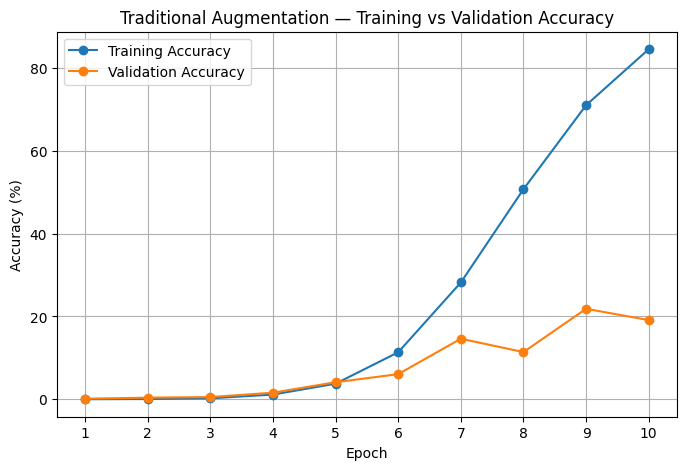

In [45]:
# Cell 32 — Plot Traditional Augmentation Training Curves

epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Traditional Augmentation — Training vs Validation Accuracy")
plt.xticks(list(epochs))
plt.legend()
plt.grid(True)
plt.show()

In [46]:
# Cell 33 — Save Traditional Augmentation Training History

history_path = (
    project_path
    / "results"
    / "CASIA_Thousand_traditional_training_history.json"
)

with open(history_path, "w") as f:
    json.dump(history, f, indent=4)

print("Training history saved successfully.")
print("Saved to:")
print(history_path)

Training history saved successfully.
Saved to:
/content/drive/MyDrive/Ocular_Project/results/CASIA_Thousand_traditional_training_history.json


In [47]:
# Cell 34 — Save Traditional Augmentation Model

traditional_model_path = (
    project_path
    / "models"
    / "CASIA_Thousand_traditional_resnet18.pth"
)

torch.save(
    traditional_model.state_dict(),
    traditional_model_path
)

print("Traditional augmentation model saved successfully.")
print("Saved to:")
print(traditional_model_path)

Traditional augmentation model saved successfully.
Saved to:
/content/drive/MyDrive/Ocular_Project/models/CASIA_Thousand_traditional_resnet18.pth


In [48]:
# Cell 35 — Evaluate Traditional Augmentation Model on Test Set

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

traditional_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = traditional_model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# Calculate evaluation metrics
test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)


print("Traditional Augmentation — Test Results")
print("-" * 50)
print(f"Test Accuracy:  {test_accuracy * 100:.2f}%")
print(f"Precision:      {test_precision * 100:.2f}%")
print(f"Recall:         {test_recall * 100:.2f}%")
print(f"F1 Score:       {test_f1 * 100:.2f}%")

Traditional Augmentation — Test Results
--------------------------------------------------
Test Accuracy:  17.35%
Precision:      14.27%
Recall:         17.35%
F1 Score:       13.78%


In [49]:
# Cell 36 — Save Traditional Augmentation Test Results

traditional_test_results = {
    "experiment": "Traditional Augmentation",
    "test_accuracy": test_accuracy,
    "precision": test_precision,
    "recall": test_recall,
    "f1_score": test_f1
}

traditional_test_results_path = (
    project_path
    / "results"
    / "CASIA_Thousand_traditional_test_results.json"
)

with open(traditional_test_results_path, "w") as f:
    json.dump(traditional_test_results, f, indent=4)

print("Traditional augmentation test results saved successfully.")
print("Saved to:")
print(traditional_test_results_path)

Traditional augmentation test results saved successfully.
Saved to:
/content/drive/MyDrive/Ocular_Project/results/CASIA_Thousand_traditional_test_results.json


In [50]:
# Cell 37 — Compare Baseline and Traditional Augmentation

comparison_df = pd.DataFrame({
    "Experiment": [
        "Baseline",
        "Traditional Augmentation"
    ],
    "Test Accuracy (%)": [
        30.18,
        test_accuracy * 100
    ],
    "Precision (%)": [
        27.24,
        test_precision * 100
    ],
    "Recall (%)": [
        30.18,
        test_recall * 100
    ],
    "F1 Score (%)": [
        26.07,
        test_f1 * 100
    ]
})

comparison_df

,Experiment,Test Accuracy (%),Precision (%),Recall (%),F1 Score (%)
0,Baseline,30.18,27.24000,30.18,26.070000
1,Traditional Augmentation,17.35,14.26588,17.35,13.782347


# Conclusion

The traditional augmentation experiment was conducted using the CASIA-Iris-Thousand
dataset with the same identity-wise image split and ResNet18 recognition
architecture used in the baseline experiment.

Traditional augmentation was applied only to the training images using mild
geometric and appearance transformations, while the validation and test sets
remained unchanged.

### Experimental Results

| Experiment | Test Accuracy | Precision | Recall | F1 Score |
|------------|--------------:|----------:|--------:|---------:|
| Baseline | 30.18% | 27.24% | 30.18% | 26.07% |
| Traditional Augmentation | 17.35% | 14.27% | 17.35% | 13.78% |

Under the current experimental configuration, the traditional augmentation
model achieved lower test performance than the baseline model.

This result provides a reference point for the subsequent GAN-based and
diffusion-based augmentation experiments.

The same test set and recognition methodology will be maintained for the
remaining experiments to enable a consistent comparison.